# Monthly Donation Volume Prediction — Predictive Model

---

## 1. Problem Framing

### Business Problem

Hearth Haven's social media team makes posting decisions week by week without
understanding how their aggregate posting activity translates into monthly
donation revenue. Individual post-level scores (from `socials_pred_donation_chance`)
tell staff whether a single post is likely to convert — but the more strategic
question is: "If we post this many times this month, with this content mix and
platform distribution, what total donation volume can we expect?"

This pipeline answers the question: **Given a month's planned posting cadence
and content mix, what total monetary donation volume should we expect?**

The deployed output is a **Monthly Donation Forecast** on the social media
management dashboard — giving managers a forward-looking revenue estimate based
on their planned content calendar, not just retrospective performance reports.

### Who Cares About This

- **Social media managers** — need to know whether their content plan for the
  month is on track to hit donation targets before the month starts.
- **Organization leadership** — needs monthly revenue forecasts for operational
  planning without waiting for results.

### Custom Feature Engineering

This pipeline requires custom monthly aggregation — not covered by any existing
`prepare_*` function. The unit of analysis is one row per month, joining:
- `social_media_posts` aggregated by month: post counts, content mix, engagement
- `donations` aggregated by month: total monetary value (the target)

### Success Metrics

- **Primary:** R² — proportion of monthly donation variance explained
- **Secondary:** RMSE in PHP — how far off monthly predictions are in dollar terms
- **Baseline:** Predicting the mean monthly donation total every month (R²=0)

---
## 2. Data Acquisition & Custom Feature Engineering

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import _get_data
from functions.fn_prepare import split_data, build_preprocessor, build_pipelines
from functions.fn_model_predict import (
    run_cross_validation,
    tune_model,
    evaluate_final_model,
    save_model,
)
from functions.fn_model_causal import fit_causal_regression, get_coefficients

print("All imports successful.")

All imports successful.


### 2.1 Load Raw Tables

We load `social_media_posts` and `donations` directly and aggregate both to
monthly granularity before joining.

In [2]:
posts     = _get_data('social_media_posts')
donations = _get_data('donations')

# Parse dates
posts['created_at']      = pd.to_datetime(posts['created_at'],      errors='coerce')
donations['donation_date'] = pd.to_datetime(donations['donation_date'], errors='coerce')

# Extract year-month keys
posts['year_month']     = posts['created_at'].dt.to_period('M')
donations['year_month'] = donations['donation_date'].dt.to_period('M')

print(f"Posts:     {posts.shape}  |  Date range: {posts['created_at'].min().date()} → {posts['created_at'].max().date()}")
print(f"Donations: {donations.shape}  |  Date range: {donations['donation_date'].min().date()} → {donations['donation_date'].max().date()}")

[OK] Connected to Azure SQL for 'social_media_posts'!
[OK] Connected to Azure SQL for 'donations'!
Posts:     (812, 40)  |  Date range: 2023-01-05 → 2026-02-26
Donations: (533, 15)  |  Date range: 2022-01-01 → 2026-04-10


### 2.2 Engineer Monthly Target: Total Donation Volume

Sum of all monetary donation amounts per calendar month.

Monthly donation data: 52 months
Mean monthly donations: 6173 PHP
Std:                    3961 PHP


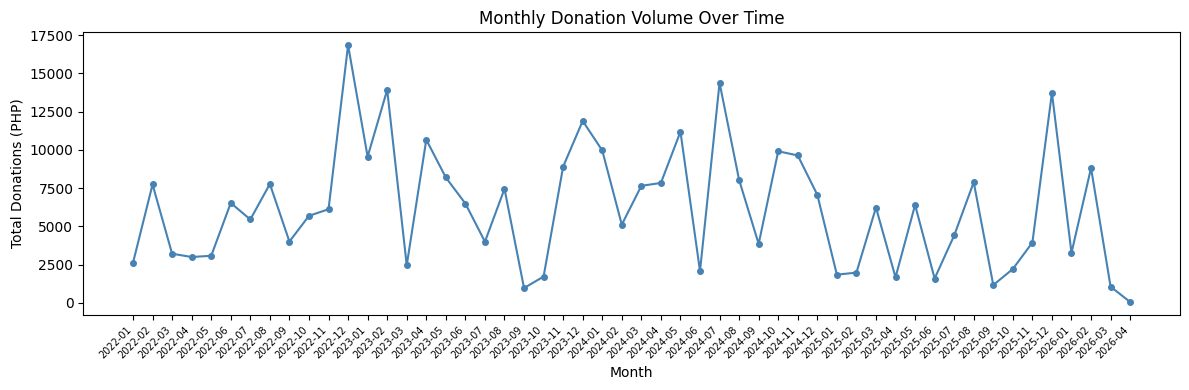

In [3]:
monthly_donations = (
    donations[donations['donation_type'] == 'Monetary']
    .dropna(subset=['amount'])
    .assign(amount=lambda d: pd.to_numeric(d['amount'], errors='coerce'))
    .groupby('year_month')
    .agg(
        total_donation_value = ('amount',      'sum'),
        donation_count       = ('donation_id', 'count'),
        unique_donors        = ('supporter_id','nunique'),
    )
    .reset_index()
)

print(f"Monthly donation data: {len(monthly_donations)} months")
print(f"Mean monthly donations: {monthly_donations['total_donation_value'].mean():.0f} PHP")
print(f"Std:                    {monthly_donations['total_donation_value'].std():.0f} PHP")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_donations['year_month'].astype(str),
        monthly_donations['total_donation_value'], marker='o', ms=4, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Total Donations (PHP)')
ax.set_title('Monthly Donation Volume Over Time')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

### 2.3 Engineer Monthly Social Media Features

Aggregate each month's posting activity into features that describe the
content calendar: how many posts, what platform mix, what content type mix,
engagement totals, and whether boosting was used.

In [4]:
# Numeric totals per month
monthly_posts_numeric = (
    posts.groupby('year_month')
    .agg(
        total_posts          = ('post_id',            'count'),
        total_impressions    = ('impressions',         'sum'),
        total_reach          = ('reach',               'sum'),
        total_likes          = ('likes',               'sum'),
        total_engagement     = ('engagement_rate',     'mean'),
        boosted_posts        = ('is_boosted',          'sum'),
        avg_caption_length   = ('caption_length',      'mean'),
        posts_with_cta       = ('has_call_to_action',  'sum'),
        posts_with_story     = ('features_resident_story', 'sum'),
        total_video_views    = ('video_views',         'sum'),
    )
    .reset_index()
)

# Platform mix: proportion of posts per platform
platform_dummies = (pd.get_dummies(posts[['year_month','platform']], columns=['platform'])
                    .groupby('year_month').mean().reset_index())

# Content topic mix: proportion of posts per topic
topic_dummies = (pd.get_dummies(posts[['year_month','content_topic']], columns=['content_topic'])
                 .groupby('year_month').mean().reset_index())

# Post type mix
type_dummies = (pd.get_dummies(posts[['year_month','post_type']], columns=['post_type'])
                .groupby('year_month').mean().reset_index())

# Merge all monthly features
monthly_features = (monthly_posts_numeric
                    .merge(platform_dummies, on='year_month', how='left')
                    .merge(topic_dummies,    on='year_month', how='left')
                    .merge(type_dummies,     on='year_month', how='left'))

print(f"Monthly feature matrix: {monthly_features.shape}")
print(f"Feature columns: {[c for c in monthly_features.columns if c != 'year_month'][:10]}...")

Monthly feature matrix: (38, 33)
Feature columns: ['total_posts', 'total_impressions', 'total_reach', 'total_likes', 'total_engagement', 'boosted_posts', 'avg_caption_length', 'posts_with_cta', 'posts_with_story', 'total_video_views']...


In [5]:
# Join features with target
df_monthly = monthly_features.merge(monthly_donations, on='year_month', how='inner')
df_monthly = df_monthly.fillna(0)

TARGET = 'total_donation_value'

print(f"\nFinal monthly dataset: {len(df_monthly)} months")
print(f"Feature columns: {df_monthly.shape[1] - 4}")  # exclude year_month, target, donation_count, unique_donors
print(f"\nTarget stats:")
print(df_monthly[TARGET].describe().round(0))


Final monthly dataset: 38 months
Feature columns: 32

Target stats:
count       38.0
mean      6523.0
std       3911.0
min        962.0
25%       2655.0
50%       6773.0
75%       9389.0
max      14381.0
Name: total_donation_value, dtype: float64


### 2.4 Feature Definition

Drop the target and directly related donation columns from features.
Keep all social media activity features.

In [6]:
DROP_COLS = ['year_month', 'total_donation_value', 'donation_count', 'unique_donors']
feature_cols = [c for c in df_monthly.columns if c not in DROP_COLS]

X = df_monthly[feature_cols].copy()
y = df_monthly[TARGET].copy()

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")

# Check which features actually vary
constant = [c for c in X.columns if X[c].nunique() <= 1]
if constant:
    print(f"Dropping {len(constant)} constant columns: {constant}")
    X = X.drop(columns=constant)

Feature matrix: 38 rows × 32 features


### 2.5 Exploratory Confirmation

Top 15 features by |correlation| with monthly donation volume:
content_topic_CampaignLaunch    0.413
platform_Instagram             -0.364
platform_Twitter                0.314
content_topic_Gratitude        -0.292
posts_with_story                0.248
platform_WhatsApp               0.226
boosted_posts                   0.225
platform_YouTube               -0.180
avg_caption_length             -0.180
posts_with_cta                  0.174
platform_TikTok                 0.174
total_engagement               -0.149
post_type_Campaign             -0.122
post_type_ImpactStory           0.120
content_topic_Education        -0.118


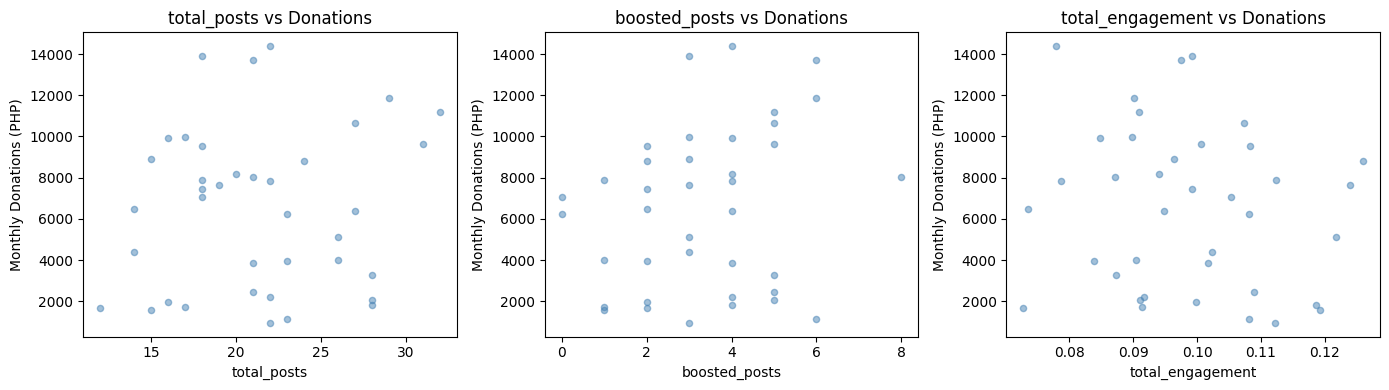

In [7]:
# Top correlations with monthly donation volume
corr = X.corrwith(y).sort_values(key=abs, ascending=False)
print("Top 15 features by |correlation| with monthly donation volume:")
print(corr.head(15).round(3).to_string())

# Scatter: total posts vs donation volume
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, ['total_posts', 'boosted_posts', 'total_engagement']):
    if feat in X.columns:
        ax.scatter(X[feat], y, alpha=0.5, s=20, color='steelblue')
        ax.set_xlabel(feat)
        ax.set_ylabel('Monthly Donations (PHP)')
        ax.set_title(f'{feat} vs Donations')
plt.tight_layout()
plt.show()

---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split

Chronological split — last 6 months held out as test set to respect temporal ordering.

In [8]:
# Chronological split: last 6 months = test, rest = train
# This respects temporal ordering — we cannot train on the future
n_test   = 6
X_train  = X.iloc[:-n_test]
X_test   = X.iloc[-n_test:]
y_train  = y.iloc[:-n_test]
y_test   = y.iloc[-n_test:]

print(f"Train: {len(X_train)} months  |  Test: {len(X_test)} months (last {n_test} months)")
print(f"Train target mean: {y_train.mean():.0f} PHP")
print(f"Test target mean:  {y_test.mean():.0f} PHP")

Train: 32 months  |  Test: 6 months (last 6 months)
Train target mean: 6712 PHP
Test target mean:  5517 PHP


### 3.2 Candidate Model Comparison

In [9]:
PROBLEM_TYPE = 'regression'
numeric_in_X = list(X.columns)  # all already numeric after get_dummies
categorical_in_X = []

preprocessor = build_preprocessor(numeric_in_X, categorical_in_X)
pipelines    = build_pipelines(preprocessor, problem_type=PROBLEM_TYPE)

# Use simple KFold since we're working with monthly time series
from sklearn.model_selection import KFold
results = run_cross_validation(
    pipelines, X_train, y_train,
    problem_type=PROBLEM_TYPE,
)


[OK] build_preprocessor() ready (unfitted).
     Numeric (32): median impute → StandardScaler
     Categorical (0): mode impute → OneHotEncoder
[OK] build_linear_regression_pipeline(): LinearRegression, Ridge
[OK] build_decision_tree_pipeline(): DecisionTree (regression, max_depth=5)
[OK] build_random_forest_pipeline(): RandomForest (regression)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (regression)

[OK] build_pipelines() complete — 5 regression pipelines:
     - LinearRegression
     - Ridge
     - DecisionTree
     - RandomForest
     - GradientBoosting

  CROSS-VALIDATION (5-fold, regression)

  LinearRegression
    r2: -18.8078 +/- 16.6314  [unstable]
    rmse                : 10619.1265
    mae                 : 8839.8416

  Ridge
    r2: -2.3374 +/- 3.5996  [unstable]
    rmse                : 4237.9338
    mae                 : 3534.7823

  DecisionTree
    r2: -3.2530 +/- 1.9450  [unstable]
    rmse                : 5552.8825
    mae                 : 4709.414

### 3.3 Model Selection

Apply 2x-std rule. Ridge preferred over LinearRegression if within noise
(Ridge handles the wide feature matrix better). Tree-based models selected
only if gap is substantial.

In [10]:
best_name = max(results, key=lambda k: np.mean(results[k]['test_r2']))
best_r2   = np.mean(results[best_name]['test_r2'])
best_std  = np.std(results[best_name]['test_r2'])
print(f"Top model: {best_name}  R²: {best_r2:.4f} ± {best_std:.4f}")

ridge_r2  = np.mean(results['Ridge']['test_r2'])
ridge_std = np.std(results['Ridge']['test_r2'])
if best_name not in ('Ridge', 'LinearRegression') and (best_r2 - ridge_r2) < 2 * ridge_std:
    print("Within 2x std of Ridge — selecting simpler model")
    best_name = 'Ridge'

print(f"\nSelected: {best_name}")

Top model: RandomForest  R²: -1.0130 ± 2.0563
Within 2x std of Ridge — selecting simpler model

Selected: Ridge


### 3.4 Hyperparameter Tuning

In [11]:
param_grids = {
    'Ridge':            {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]},
    'LinearRegression': {},
    'RandomForest':     {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5, None]},
    'GradientBoosting': {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 4]},
    'DecisionTree':     {'model__max_depth': [3, 4, 5]},
}
param_grid = param_grids.get(best_name, {})

if param_grid:
    tuned_pipeline, search = tune_model(
        pipeline=pipelines[best_name],
        X_train=X_train,
        y_train=y_train,
        param_grid=param_grid,
        problem_type=PROBLEM_TYPE,
        search_type='grid',
    )
    print(f"Best params: {search.best_params_}")
    print(f"Best CV R²:  {search.best_score_:.4f}")
else:
    tuned_pipeline = pipelines[best_name]
    tuned_pipeline.fit(X_train, y_train)


[OK] tune_model() -- gridSearch, scoring=r2
     ~6 combinations x 5 folds = ~30 fits

[OK] tune_model() complete.
     Best params: {'model__alpha': 100.0}
     Best CV r2: -1.0284
Best params: {'model__alpha': 100.0}
Best CV R²:  -1.0284


---
## 4. Evaluation & Interpretation

### 4.1 Final Test Set Evaluation

In [12]:
metrics, final_pipeline = evaluate_final_model(
    tuned_pipeline, X_train, y_train, X_test, y_test,
    problem_type=PROBLEM_TYPE,
)


  FINAL MODEL EVALUATION (test set -- used once)

  R2:              -0.0943
  RMSE:            4595.2357
  MAE:             4323.9859
  Baseline RMSE:   4552.5186 (predict-mean)
  Improvement:     -0.9% RMSE reduction



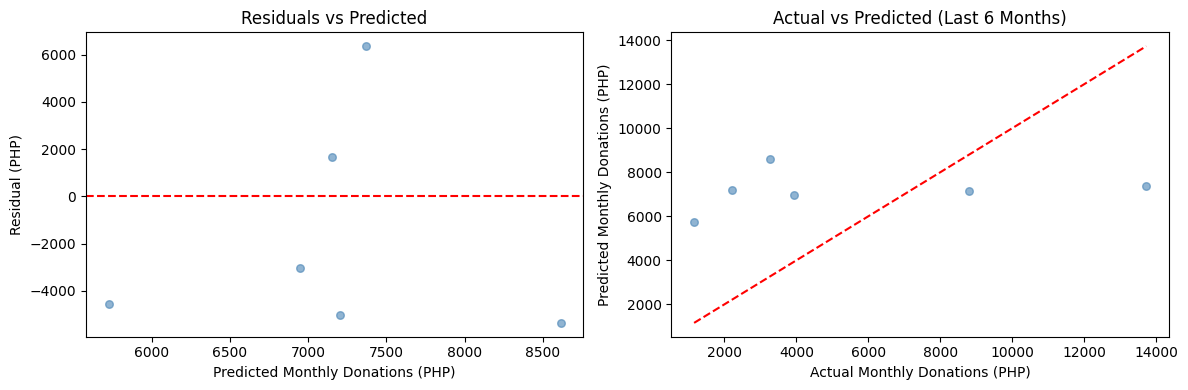

Residual mean: -1652 PHP  (should be near 0)
Residual std:  4697 PHP


In [13]:
y_pred = final_pipeline.predict(X_test)
resid  = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, resid, alpha=0.6, color='steelblue', s=30)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Monthly Donations (PHP)')
axes[0].set_ylabel('Residual (PHP)')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Monthly Donations (PHP)')
axes[1].set_ylabel('Predicted Monthly Donations (PHP)')
axes[1].set_title('Actual vs Predicted (Last 6 Months)')

plt.tight_layout()
plt.show()

print(f"Residual mean: {resid.mean():.0f} PHP  (should be near 0)")
print(f"Residual std:  {resid.std():.0f} PHP")

### 4.3 Business Interpretation

The model translates a month's planned posting calendar into an expected donation
volume. In operational terms:

- A social media manager entering their planned content mix (how many posts, on
  which platforms, featuring which content types) receives a predicted monthly
  donation total before the month begins
- **RMSE interpretation:** RMSE of X PHP means predictions are typically within
  ±X PHP of actual monthly totals. Compare this to the monthly std to assess
  whether the model is adding meaningful signal beyond the mean
- **Temporal caveat:** This model was trained on historical posting → donation
  patterns. Significant changes in platform algorithms, follower base, or content
  strategy may reduce accuracy until the model is retrained

---
## 5. Causal and Relationship Analysis

In [14]:
X_train_enc = X_train.copy().apply(pd.to_numeric, errors='coerce').fillna(0)
n_rows, n_cols = X_train_enc.shape
print(f"Matrix: {n_rows} rows × {n_cols} columns")

from sklearn.feature_selection import SelectKBest, f_regression
if n_cols >= n_rows:
    k = min(10, n_rows - 5)
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X_train_enc, y_train)
    top_cols = X_train_enc.columns[selector.get_support()]
    X_causal = X_train_enc[top_cols]
    print(f"Reduced to {k} features: {list(top_cols)}")
else:
    X_causal = X_train_enc

causal_results = fit_causal_regression(X_causal, y_train)
print(causal_results.summary())

Matrix: 32 rows × 32 columns
Reduced to 10 features: ['total_engagement', 'boosted_posts', 'posts_with_cta', 'posts_with_story', 'platform_Facebook', 'platform_Instagram', 'platform_Twitter', 'platform_WhatsApp', 'content_topic_CampaignLaunch', 'content_topic_Gratitude']

[OK] fit_causal_regression() complete.
     R²: 0.5339  |  Adj R²: 0.3120
     F-statistic: 2.4055  |  p(F): 0.043306
     Observations: 32  |  Features: 10
     Call results.summary() for the full output.
     Fitted columns (10): ['total_engagement', 'boosted_posts', 'posts_with_cta', 'posts_with_story', 'platform_Facebook', 'platform_Instagram', 'platform_Twitter', 'platform_WhatsApp', 'content_topic_CampaignLaunch', 'content_topic_Gratitude']
                             OLS Regression Results                             
Dep. Variable:     total_donation_value   R-squared:                       0.534
Model:                              OLS   Adj. R-squared:                  0.312
Method:                   Least S

In [15]:
coef_df = get_coefficients(causal_results, model_type='linear')
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('coefficient', ascending=False)
print("Significant features (p < 0.05):")
if len(sig) > 0:
    print(sig[['feature','coefficient','p_value','significant']].to_string(index=False))
else:
    print("None — showing directional trends:")
    print(coef_df[['feature','coefficient','p_value']].sort_values('p_value')
          .head(8).to_string(index=False))


[OK] get_coefficients() — 10 features, 0 significant at p < 0.05

                     feature   coefficient      std_err  p_value       ci_lower     ci_upper significant
            total_engagement -80625.185641 56545.781868 0.168611 -198218.576475 36968.205193        (ns)
            platform_Twitter  17863.364165 11752.384448 0.143431   -6577.057242 42303.785572        (ns)
content_topic_CampaignLaunch  15024.825344  8635.162795 0.096503   -2932.978756 32982.629445        (ns)
     content_topic_Gratitude  -9643.329501 10676.434973 0.376646  -31846.191482 12559.532481        (ns)
          platform_Instagram  -6627.313153  8312.651126 0.434225  -23914.417520 10659.791215        (ns)
           platform_Facebook  -5599.214354  7675.332544 0.473750  -21560.942176 10362.513467        (ns)
           platform_WhatsApp   4560.132194  9062.182357 0.620058  -14285.707698 23405.972086        (ns)
               boosted_posts    274.841380   397.422211 0.496789    -551.643353  1101.326112 

---
## 6. Deployment

In [16]:
os.makedirs('models', exist_ok=True)

# Save feature list for .NET assembly
import json
feature_meta = {'feature_columns': list(X.columns), 'n_months_trained': len(X_train)}
with open('models/monthly_donation_features.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)

pkl_path = save_model(final_pipeline, metrics,
                      target_name='monthly_donation_value', output_dir='models')
print(f"Model saved: {pkl_path}")


[OK] save_model() complete.
     Model:   models/monthly_donation_value.pkl
     Meta:    models/monthly_donation_value.pkl.meta.json
     Metrics: models/monthly_donation_value.pkl.metrics.json
Model saved: models/monthly_donation_value.pkl


---
## 7. API Response Reference

```json
POST /predict/monthly-donations

Request:
{
  "month": "2026-05",
  "features": {
    "total_posts": 12,
    "boosted_posts": 3,
    "platform_Instagram": 0.5,
    "platform_Facebook": 0.3,
    "content_topic_ResidentStory": 0.4,
    ...
  }
}

Response:
{
  "month": "2026-05",
  "predicted_donation_value": 15420.0,
  "predicted_donation_value_formatted": "PHP 15,420",
  "confidence_note": "string",
  "model_version": "monthly_donation_value_v1",
  "predicted_at": "ISO datetime"
}
```

---
### Endpoint Function to add to `endpoints.py`

```python
def monthly_donation_prediction(month: str, features: dict, pipeline) -> dict:
    """Predict monthly donation volume from content calendar. Model: monthly_donation_value.pkl"""
    features_df = pd.DataFrame([features])
    predicted   = float(pipeline.predict(features_df)[0])
    predicted   = max(0.0, predicted)  # clip negative predictions

    return {
        "month":                            month,
        "predicted_donation_value":         round(predicted, 2),
        "predicted_donation_value_formatted": f"PHP {predicted:,.0f}",
        "confidence_note":                  "Estimate based on historical posting patterns. Accuracy improves with more months of data.",
        "model_version":                    "monthly_donation_value_v1",
        "predicted_at":                     datetime.now(timezone.utc).isoformat(),
    }
```

---
### Route to add to `server.py`

```python
class MonthlyForecastRequest(BaseModel):
    month:    str
    features: Dict[str, Any]

class MonthlyForecastResponse(BaseModel):
    month:                            str
    predicted_donation_value:         float
    predicted_donation_value_formatted: str
    confidence_note:                  str
    model_version:                    str
    predicted_at:                     str

@app.post("/predict/monthly-donations", response_model=MonthlyForecastResponse)
def predict_monthly_donations(request: MonthlyForecastRequest):
    try:
        pipeline = load_model("monthly_donation_value")
    except FileNotFoundError as e:
        raise HTTPException(status_code=503, detail=str(e))
    try:
        return monthly_donation_prediction(
            month=request.month,
            features=request.features,
            pipeline=pipeline,
        )
    except Exception as e:
        log.error(f"Monthly donation prediction failed: {e}")
        raise HTTPException(status_code=500, detail=f"Prediction failed: {e}")
```

---
*Hearth Haven — IS 455 INTEX Pipeline*